# TFM - Baseline CNN para clasificación de defectos (NEU-DET)

Este notebook implementa un modelo *baseline* de clasificación de imágenes con PyTorch para las 6 clases del dataset NEU-DET: `crazing`, `inclusion`, `patches`, `pitted_surface`, `rolled-in_scale` y `scratches`.

La tubería incluye: carga de datos con `ImageFolder` usando carpetas separadas para entrenamiento y validación, definición de una CNN personalizada y entrenamiento con monitorización de *loss* y *accuracy*.

In [ ]:
# ============================
# 1) Importaciones y configuración
# ============================
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_fscore_support
)
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms

# Fijamos semillas para mejorar la reproducibilidad de los experimentos.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Selección automática de dispositivo: GPU si está disponible, en caso contrario CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo en uso: {device}')

Dispositivo en uso: cuda
PyTorch: 2.2.1+cu121
CUDA disponible: True


In [13]:
# ==========================================
# 2) Transformaciones y carga del dataset
# ==========================================
# Resolver rutas de forma robusta para que funcione tanto si el kernel arranca
# en la carpeta del proyecto como en notebooks/.
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / 'data').exists() else cwd.parent

if not (project_root / 'data').exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta 'data' desde el directorio actual: {cwd}"
    )

train_dir = project_root / 'data' / 'clasificacion_full'
val_dir = project_root / 'data' / 'val'
test_dir = project_root / 'data' / 'test'

print(f'Directorio de trabajo del kernel: {cwd}')
print(f'Raíz de proyecto detectada: {project_root}')

for required_dir in [train_dir, val_dir, test_dir]:
    if not required_dir.exists():
        raise FileNotFoundError(f'No existe la carpeta: {required_dir.resolve()}')

# Transformaciones de entrenamiento con data augmentation.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones de validación (sin augmentation para evaluación objetiva).
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset base (train) para extraer clases y configurar el modelo.
base_dataset = datasets.ImageFolder(root=train_dir)
class_names = base_dataset.classes
num_classes = len(class_names)

print(f'Número de clases: {num_classes}')
print(f'Clases detectadas: {class_names}')
print(f'Imágenes train: {len(datasets.ImageFolder(root=train_dir))}')
print(f'Imágenes val:   {len(datasets.ImageFolder(root=val_dir))}')
print(f'Imágenes test:  {len(datasets.ImageFolder(root=test_dir))}')

Directorio de trabajo del kernel: C:\Users\Usuario\Desktop\TFM_CNN_Custom\notebooks
Raíz de proyecto detectada: C:\Users\Usuario\Desktop\TFM_CNN_Custom
Número de clases: 6
Clases detectadas: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Imágenes train: 1439
Imágenes val:   180
Imágenes test:  180


In [14]:
# ==================================================
# 3) Carga de Train/Validation y DataLoaders
# ==================================================
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)

# Validar que la codificación de clases sea consistente entre train y val.
if train_dataset.class_to_idx != val_dataset.class_to_idx:
    raise ValueError(
        f'Mapeo de clases distinto entre train y val. '
        f'train={train_dataset.class_to_idx}, val={val_dataset.class_to_idx}'
    )

batch_size = 32
num_workers = 0  # En Windows suele ser más estable comenzar con 0.

# Balanceo: muestreador ponderado para compensar clases minoritarias.
train_targets = np.array(train_dataset.targets)
class_sample_count = np.bincount(train_targets, minlength=num_classes)
class_sample_count = np.clip(class_sample_count, a_min=1, a_max=None)
class_weights_np = 1.0 / class_sample_count
sample_weights = class_weights_np[train_targets]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

# Pesos de clase para la función de pérdida.
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    sampler=sampler,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
 )

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
 )

print(f'Muestras de entrenamiento: {len(train_dataset)}')
print(f'Muestras de validación: {len(val_dataset)}')
print(f'Pesos por clase: {dict(zip(class_names, class_weights_np.round(4)))}')

Muestras de entrenamiento: 1439
Muestras de validación: 180
Pesos por clase: {'crazing': 0.0042, 'inclusion': 0.0042, 'patches': 0.004, 'pitted_surface': 0.0041, 'rolled-in_scale': 0.0042, 'scratches': 0.0043}


In [15]:
# ===============================================
# 4) Definición de la CNN baseline personalizada
# ===============================================
class CustomSteelCNN(nn.Module):
    """
    CNN mejorada para clasificación multiclase en NEU-DET.
    Arquitectura: 3 bloques Conv + BatchNorm + ReLU + MaxPool,
    seguidos de un clasificador denso con regularización Dropout.
    """

    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Reduce el mapa espacial para contener el número de parámetros.
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CustomSteelCNN(num_classes=num_classes).to(device)
print(model)

CustomSteelCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (

In [16]:
# =============================================
# 5) Función de pérdida, optimizador y scheduler
# =============================================
# Loss ponderada + label smoothing para mejorar generalización.
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)

# AdamW suele generalizar mejor que Adam en CNNs de clasificación.
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

# Scheduler coseno para una caída suave del learning rate.
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20,
    eta_min=1e-6
)

# Mixed precision en GPU para entrenamiento más estable/rápido.
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print('Configuración de entrenamiento:')
print(f'- Loss: {criterion.__class__.__name__} (weighted + label_smoothing=0.05)')
print(f'- Optimizador: {optimizer.__class__.__name__}')
print('- Scheduler: CosineAnnealingLR')
print(f'- Mixed precision: {torch.cuda.is_available()}')

Configuración de entrenamiento:
- Loss: CrossEntropyLoss (weighted + label_smoothing=0.05)
- Optimizador: AdamW
- Scheduler: CosineAnnealingLR
- Mixed precision: True


In [17]:
# =========================================================
# 6) Funciones auxiliares para entrenar y validar por epoch
# =========================================================
def run_epoch(
    model,
    dataloader,
    criterion,
    optimizer=None,
    device='cpu',
    scaler=None,
    max_grad_norm=1.0,
 ):
    """
    Ejecuta una época de entrenamiento o validación.
    Si 'optimizer' es None, realiza solo validación.
    Retorna loss, accuracy y métricas macro (precision, recall, f1).
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if is_train:
            if scaler is not None and scaler.is_enabled():
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        batch_size_current = labels.size(0)
        running_loss += loss.item() * batch_size_current
        running_corrects += (preds == labels).sum().item()
        total_samples += batch_size_current

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples

    # Calcular métricas macro (precisión, recall, F1) por época.
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )

    return epoch_loss, epoch_acc, precision_macro, recall_macro, f1_macro

In [18]:
# ==============================================
# 7) Bucle principal de entrenamiento con Early Stopping
# ==============================================
num_epochs = 100
patience = 12
patience_counter = 0

history = {
    'train_loss': [],
    'train_acc': [],
    'train_precision_macro': [],
    'train_recall_macro': [],
    'train_f1_macro': [],
    'val_loss': [],
    'val_acc': [],
    'val_precision_macro': [],
    'val_recall_macro': [],
    'val_f1_macro': [],
    'lr': []
}

best_val_acc = 0.0
best_val_f1 = 0.0
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    train_loss, train_acc, train_prec, train_rec, train_f1 = run_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        scaler=scaler,
        max_grad_norm=1.0
    )

    val_loss, val_acc, val_prec, val_rec, val_f1 = run_epoch(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        optimizer=None,
        device=device,
        scaler=None,
        max_grad_norm=1.0
    )

    # Scheduler por epoch.
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_precision_macro'].append(train_prec)
    history['train_recall_macro'].append(train_rec)
    history['train_f1_macro'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision_macro'].append(val_prec)
    history['val_recall_macro'].append(val_rec)
    history['val_f1_macro'].append(val_f1)
    history['lr'].append(current_lr)

    # Guardamos el mejor estado según F1 macro de validación.
    improved = val_f1 > best_val_f1
    if improved:
        best_val_f1 = val_f1
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f'Epoch [{epoch + 1}/{num_epochs}] | '
        f'LR: {current_lr:.6f} | '
        f'Train [Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, P: {train_prec:.4f}, R: {train_rec:.4f}, F1: {train_f1:.4f}] | '
        f'Val [Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, P: {val_prec:.4f}, R: {val_rec:.4f}, F1: {val_f1:.4f}]'
    )

    if patience_counter >= patience:
        print(f'\nEarly Stopping activado en epoch {epoch + 1}/{num_epochs}.')
        break

# Restauramos el mejor modelo encontrado durante el entrenamiento.
model.load_state_dict(best_model_state)
print(f'Mejor Val F1:  {best_val_f1:.4f}')
print(f'Val Acc asociada: {best_val_acc:.4f}')

Epoch [1/100] | LR: 0.000298 | Train [Loss: 1.4556, Acc: 0.4336, P: 0.4314, R: 0.4331, F1: 0.4247] | Val [Loss: 1.2139, Acc: 0.6000, P: 0.6676, R: 0.5972, F1: 0.5854]
Epoch [2/100] | LR: 0.000293 | Train [Loss: 1.0789, Acc: 0.6247, P: 0.6370, R: 0.6225, F1: 0.6263] | Val [Loss: 0.8702, Acc: 0.7056, P: 0.7741, R: 0.7047, F1: 0.6995]
Epoch [3/100] | LR: 0.000284 | Train [Loss: 0.9063, Acc: 0.6970, P: 0.7039, R: 0.6972, F1: 0.6989] | Val [Loss: 0.7594, Acc: 0.7611, P: 0.7860, R: 0.7673, F1: 0.7710]
Epoch [4/100] | LR: 0.000271 | Train [Loss: 0.8663, Acc: 0.7144, P: 0.7142, R: 0.7121, F1: 0.7123] | Val [Loss: 0.6743, Acc: 0.8111, P: 0.8593, R: 0.8214, F1: 0.8207]
Epoch [5/100] | LR: 0.000256 | Train [Loss: 0.7887, Acc: 0.7693, P: 0.7720, R: 0.7718, F1: 0.7712] | Val [Loss: 0.7081, Acc: 0.7667, P: 0.8000, R: 0.7682, F1: 0.7700]
Epoch [6/100] | LR: 0.000238 | Train [Loss: 0.7486, Acc: 0.7860, P: 0.7891, R: 0.7860, F1: 0.7870] | Val [Loss: 0.6465, Acc: 0.8056, P: 0.8573, R: 0.8126, F1: 0.8129

In [19]:
# ==============================================
# 8) Guardado del mejor modelo entrenado
# ==============================================
output_model_path = Path('../src/custom_steel_cnn_baseline_best.pth')
output_model_path.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        'model_state_dict': model.state_dict(),
        'class_names': class_names,
        'best_val_acc': best_val_acc,
        'best_val_f1': best_val_f1,
        'history': history
    },
    output_model_path
)

print(f'Mejor modelo guardado en: {output_model_path.resolve()}')

Mejor modelo guardado en: C:\Users\Usuario\Desktop\TFM_CNN_Custom\src\custom_steel_cnn_baseline_best.pth


## Evaluación visual del entrenamiento

Las siguientes celdas permiten analizar el comportamiento del modelo mediante curvas de aprendizaje, evolución del learning rate y matriz de confusión sobre el conjunto de validación.

Gráfica guardada en: ..\resultados\baseline_cnn\curvas_aprendizaje.png


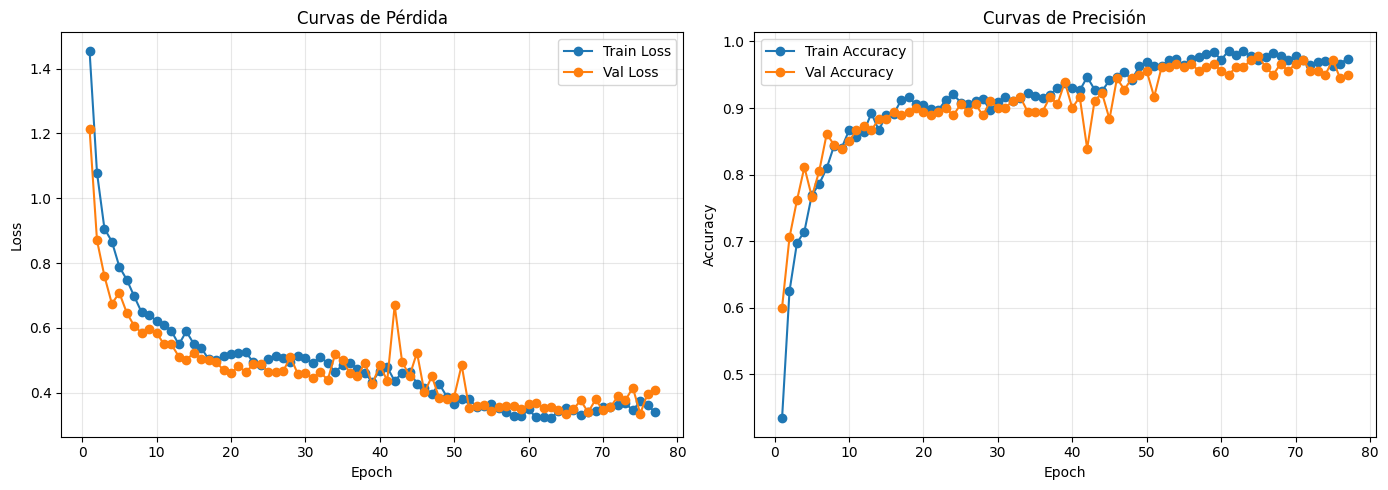

Gráfica guardada en: ..\resultados\baseline_cnn\evolucion_lr.png


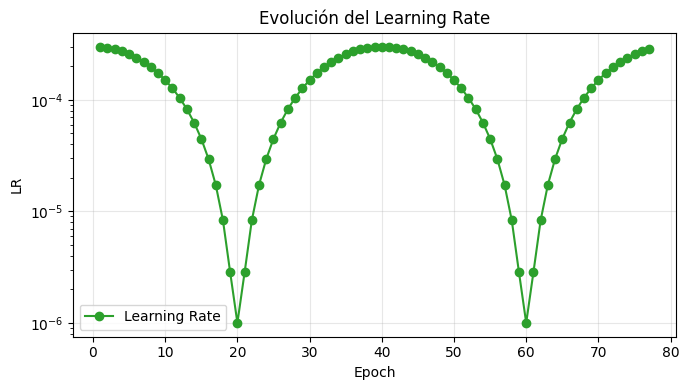

Gráfica guardada en: ..\resultados\baseline_cnn\metricas_macro.png


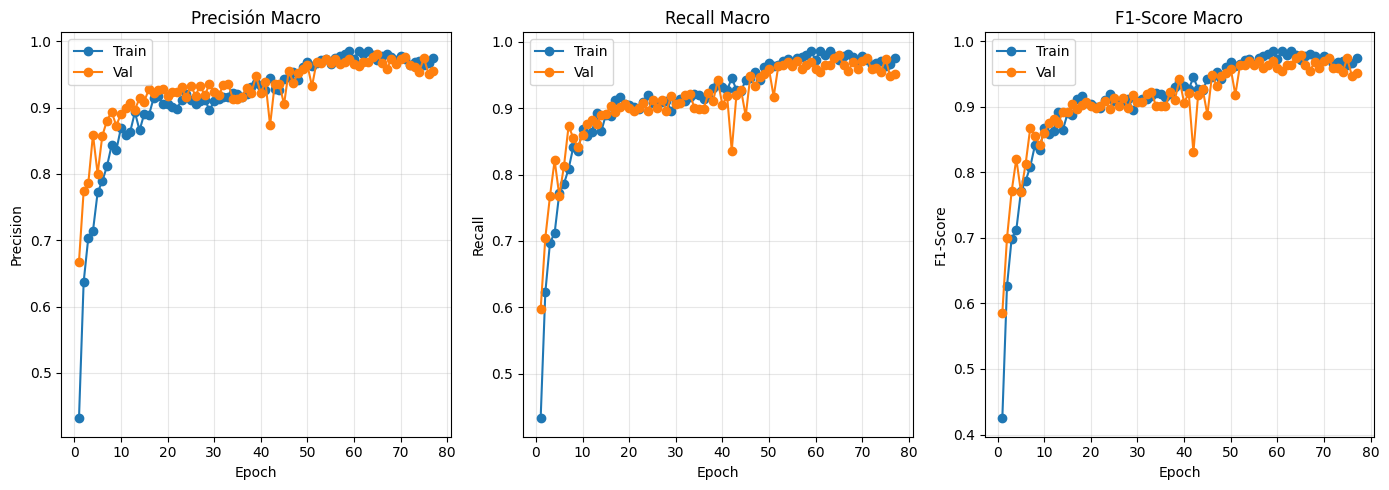

In [20]:
# ==============================================
# 9) Curvas de aprendizaje (Loss y Accuracy) con exportación
# ==============================================
# Crear directorio de resultados si no existe.
results_dir = Path('../resultados/baseline_cnn/')
results_dir.mkdir(parents=True, exist_ok=True)

# Solo usamos epochs hasta donde se detuvo el entrenamiento.
num_epochs_trained = len(history['train_loss'])
epochs = np.arange(1, num_epochs_trained + 1)

# Figura 1: Curvas de pérdida y precisión.
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
plt.title('Curvas de Pérdida')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(epochs, history['val_acc'], label='Val Accuracy', marker='o')
plt.title('Curvas de Precisión')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
learning_curves_path = results_dir / 'curvas_aprendizaje.png'
plt.savefig(learning_curves_path, dpi=300, bbox_inches='tight')
print(f'Gráfica guardada en: {learning_curves_path}')
plt.show()

# Figura 2: Evolución del Learning Rate.
plt.figure(figsize=(7, 4))
plt.plot(epochs, history['lr'], label='Learning Rate', marker='o', color='tab:green')
plt.title('Evolución del Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
lr_path = results_dir / 'evolucion_lr.png'
plt.savefig(lr_path, dpi=300, bbox_inches='tight')
print(f'Gráfica guardada en: {lr_path}')
plt.show()

# Figura 3: Curvas de métricas macro (Precision, Recall, F1).
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, history['train_precision_macro'], label='Train', marker='o')
plt.plot(epochs, history['val_precision_macro'], label='Val', marker='o')
plt.title('Precisión Macro')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, history['train_recall_macro'], label='Train', marker='o')
plt.plot(epochs, history['val_recall_macro'], label='Val', marker='o')
plt.title('Recall Macro')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, history['train_f1_macro'], label='Train', marker='o')
plt.plot(epochs, history['val_f1_macro'], label='Val', marker='o')
plt.title('F1-Score Macro')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
metrics_path = results_dir / 'metricas_macro.png'
plt.savefig(metrics_path, dpi=300, bbox_inches='tight')
print(f'Gráfica guardada en: {metrics_path}')
plt.show()

Matriz de confusión guardada en: ..\resultados\baseline_cnn\matriz_confusion.png


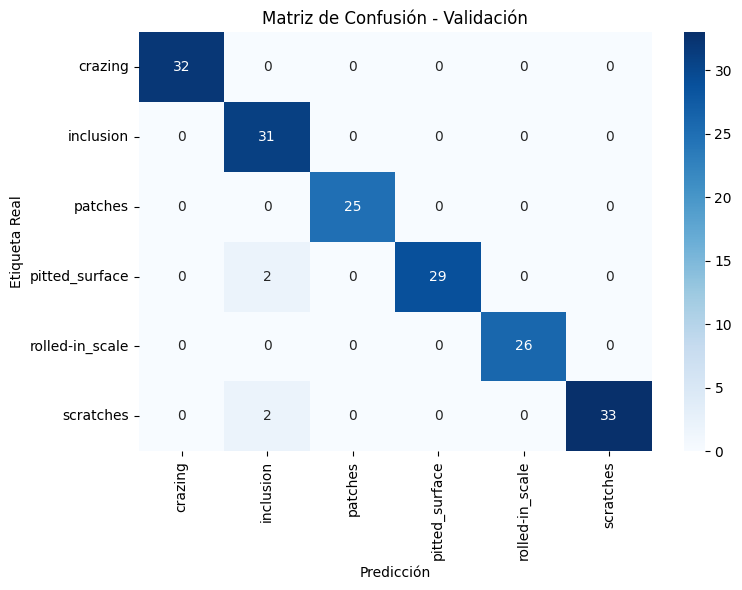

Reporte de clasificación (validación):
                 precision    recall  f1-score   support

        crazing     1.0000    1.0000    1.0000        32
      inclusion     0.8857    1.0000    0.9394        31
        patches     1.0000    1.0000    1.0000        25
 pitted_surface     1.0000    0.9355    0.9667        31
rolled-in_scale     1.0000    1.0000    1.0000        26
      scratches     1.0000    0.9429    0.9706        35

       accuracy                         0.9778       180
      macro avg     0.9810    0.9797    0.9794       180
   weighted avg     0.9803    0.9778    0.9781       180

Reporte guardado en: ..\resultados\baseline_cnn\reporte_clasificacion.txt


In [21]:
# ==============================================
# 10) Matriz de confusión y reporte de clasificación con exportación
# ==============================================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Matriz de Confusión - Validación')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.tight_layout()
cm_path = results_dir / 'matriz_confusion.png'
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f'Matriz de confusión guardada en: {cm_path}')
plt.show()

print('Reporte de clasificación (validación):')
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

# Guardar reporte como texto en archivo.
report_path = results_dir / 'reporte_clasificacion.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)
print(f'Reporte guardado en: {report_path}')

Cargando los mejores pesos desde: C:\Users\Usuario\Desktop\TFM_CNN_Custom\src\custom_steel_cnn_baseline_best.pth
Resultados en TEST externo:
Accuracy:  0.9944
Precision macro: 0.9949
Recall macro:    0.9931
F1 macro:        0.9939
Matriz de confusión test guardada en: ..\resultados\baseline_cnn\evaluacion_test\matriz_confusion_test.png


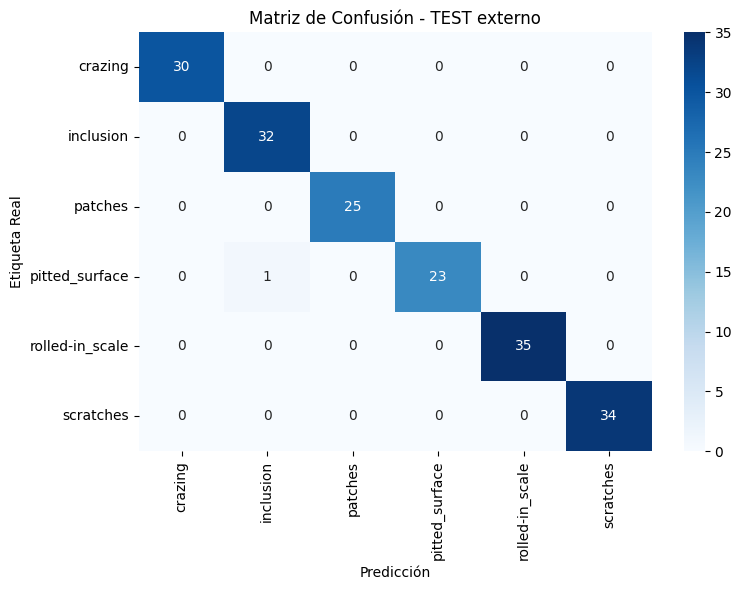

Reporte de clasificación (TEST):
                 precision    recall  f1-score   support

        crazing     1.0000    1.0000    1.0000        30
      inclusion     0.9697    1.0000    0.9846        32
        patches     1.0000    1.0000    1.0000        25
 pitted_surface     1.0000    0.9583    0.9787        24
rolled-in_scale     1.0000    1.0000    1.0000        35
      scratches     1.0000    1.0000    1.0000        34

       accuracy                         0.9944       180
      macro avg     0.9949    0.9931    0.9939       180
   weighted avg     0.9946    0.9944    0.9944       180

Reporte de test guardado en: ..\resultados\baseline_cnn\evaluacion_test\reporte_clasificacion_test.txt


In [22]:
# ==============================================
# 11) Evaluación final en set TEST externo (no usado en entrenamiento)
# ==============================================
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

if 'results_dir' not in globals():
    results_dir = Path('../resultados/baseline_cnn/')
    results_dir.mkdir(parents=True, exist_ok=True)

# Reusar la raíz detectada en la celda 2; si no existe, detectarla aquí también.
if 'project_root' not in globals():
    cwd = Path.cwd().resolve()
    project_root = cwd if (cwd / 'data').exists() else cwd.parent

test_dir = project_root / 'data' / 'test'
if not test_dir.exists():
    raise FileNotFoundError(f'No existe la carpeta de test: {test_dir.resolve()}')

test_dataset = ImageFolder(root=str(test_dir), transform=val_transform)

# Validar que las clases del test coincidan con las clases del entrenamiento.
if set(test_dataset.classes) != set(class_names):
    raise ValueError(
        f'Clases distintas entre train y test. train={class_names}, test={test_dataset.classes}'
    )

train_class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_map_test_to_train = {
    test_idx: train_class_to_idx[class_name]
    for class_name, test_idx in test_dataset.class_to_idx.items()
}

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

ruta_mejor_modelo = project_root / 'src' / 'custom_steel_cnn_baseline_best.pth'

if ruta_mejor_modelo.exists():
    print(f"Cargando los mejores pesos desde: {ruta_mejor_modelo}")
    checkpoint = torch.load(ruta_mejor_modelo, map_location=device)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
else:
    print('ADVERTENCIA: No se encontró el archivo .pth guardado. Usando el modelo en memoria RAM.')

model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        mapped_labels = [idx_map_test_to_train[int(l)] for l in labels.numpy()]

        test_preds.extend(preds)
        test_labels.extend(mapped_labels)

test_acc = accuracy_score(test_labels, test_preds)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    test_labels,
    test_preds,
    average='macro',
    zero_division=0,
)

print('Resultados en TEST externo:')
print(f'Accuracy:  {test_acc:.4f}')
print(f'Precision macro: {prec_macro:.4f}')
print(f'Recall macro:    {rec_macro:.4f}')
print(f'F1 macro:        {f1_macro:.4f}')

cm_test = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('Matriz de Confusión - TEST externo')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.tight_layout()

test_results_dir = results_dir / 'evaluacion_test'
test_results_dir.mkdir(parents=True, exist_ok=True)

cm_test_path = test_results_dir / 'matriz_confusion_test.png'
plt.savefig(cm_test_path, dpi=300, bbox_inches='tight')
print(f'Matriz de confusión test guardada en: {cm_test_path}')
plt.show()

report_test = classification_report(
    test_labels,
    test_preds,
    target_names=class_names,
    digits=4,
)
print('Reporte de clasificación (TEST):')
print(report_test)

report_test_path = test_results_dir / 'reporte_clasificacion_test.txt'
with open(report_test_path, 'w', encoding='utf-8') as f:
    f.write(report_test)
print(f'Reporte de test guardado en: {report_test_path}')